# Classification analysis (supermarket data)

## Libraries and imports

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import tree
from sklearn.metrics import RocCurveDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Show current working directory
print(os.getcwd())

# Show version of scikit-learn
import sklearn
sklearn.__version__


/workspaces/data_analytics/Week_09


'1.5.1'

## Load data

In [38]:
columns = ['id', 'bfs_name', 'bfs_number', 'lat', 'lon', 'brand', 'pop', 'pop_dens', 'frg_pct', 'emp']
df_supermarkets = pd.read_csv('supermarkets_data_enriched.csv', usecols=columns)
df_supermarkets.head()

,id,lat,lon,brand,bfs_name,bfs_number,pop,pop_dens,frg_pct,emp
0,33126515,47.155616,9.037915,Spar,Schänis,3315,3876,97.142857,13.054696,1408.0
1,280130028,47.155492,9.039666,ALDI,Schänis,3315,3876,97.142857,13.054696,1408.0
2,6122906632,47.158959,9.044477,Denner,Schänis,3315,3876,97.142857,13.054696,1408.0
3,9019298862,47.155185,9.038472,Lidl,Schänis,3315,3876,97.142857,13.054696,1408.0
4,36726161,47.226191,8.980329,Migros,Uznach,3339,6489,860.610080,27.862537,3500.0


## Cleaning and subset

In [39]:
df_supermarkets = df_supermarkets.dropna()

df_sub = df_supermarkets[df_supermarkets['brand'].isin(['Migros', 'Volg'])]
df_sub.head()

,id,lat,lon,brand,bfs_name,bfs_number,pop,pop_dens,frg_pct,emp
4,36726161,47.226191,8.980329,Migros,Uznach,3339,6489,860.610080,27.862537,3500.0
8,48932835,47.375020,8.522895,Migros,Zürich,261,420217,4778.994655,32.458468,491193.0
11,83330862,47.344749,8.529981,Migros,Zürich,261,420217,4778.994655,32.458468,491193.0
12,119249170,47.375255,8.536107,Migros,Zürich,261,420217,4778.994655,32.458468,491193.0
15,262400822,47.364072,8.530945,Migros,Zürich,261,420217,4778.994655,32.458468,491193.0


In [40]:
df_sub['brand'].value_counts()

brand
Migros    486
Volg      210
Name: count, dtype: int64

## Training and test samples

In [41]:
X_train, X_test, y_train, y_test = train_test_split(df_sub[['pop', 
                                                          'pop_dens', 
                                                          'frg_pct', 
                                                          'emp']], 
                                                    df_sub['brand'], 
                                                    test_size=0.30, 
                                                    random_state=42)



## Tree

In [42]:
clf = DecisionTreeClassifier(random_state=42, 
                             max_depth=3)

# Train the classification tree model 
clf = clf.fit(X_train, y_train)

# Make model predictions
y_pred = clf.predict(X_test)

### Text representation

In [43]:
tree.export_text(clf, feature_names=list(X_train.columns))

'|--- emp <= 1399.00\n|   |--- frg_pct <= 18.31\n|   |   |--- pop <= 2598.50\n|   |   |   |--- class: Volg\n|   |   |--- pop >  2598.50\n|   |   |   |--- class: Volg\n|   |--- frg_pct >  18.31\n|   |   |--- pop <= 1851.00\n|   |   |   |--- class: Volg\n|   |   |--- pop >  1851.00\n|   |   |   |--- class: Migros\n|--- emp >  1399.00\n|   |--- pop_dens <= 1492.46\n|   |   |--- pop_dens <= 30.11\n|   |   |   |--- class: Volg\n|   |   |--- pop_dens >  30.11\n|   |   |   |--- class: Migros\n|   |--- pop_dens >  1492.46\n|   |   |--- frg_pct <= 20.66\n|   |   |   |--- class: Migros\n|   |   |--- frg_pct >  20.66\n|   |   |   |--- class: Migros\n'

### Graphic visualization

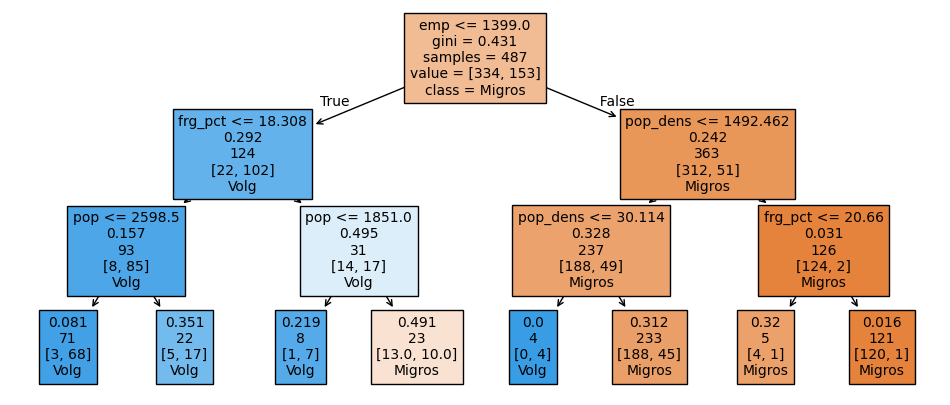

In [44]:
# For the meaning of numbers in boxes see root node
fig = plt.figure(figsize=(12,5))
tree_plot = tree.plot_tree(clf, 
                   feature_names=list(X_train.columns),  
                   class_names=['Migros', 'Volg'],
                   filled=True,
                   fontsize=10,
                   label='root')

### Confussion matrix and classification report

In [45]:
# Confusion matrix
print('Confusion matrix')
print(confusion_matrix(y_test, y_pred), '\n')

# Classification report
print('Classification report')
print(classification_report(y_test, y_pred))

Confusion matrix
[[143   9]
 [ 23  34]] 

Classification report
              precision    recall  f1-score   support

      Migros       0.86      0.94      0.90       152
        Volg       0.79      0.60      0.68        57

    accuracy                           0.85       209
   macro avg       0.83      0.77      0.79       209
weighted avg       0.84      0.85      0.84       209



### ROC curve and AUC

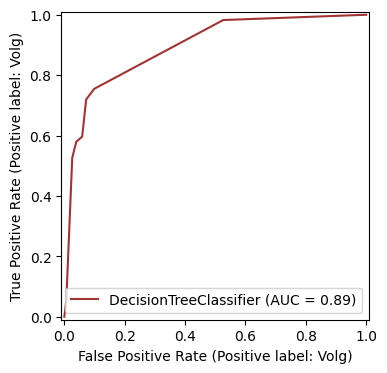

In [46]:
# Plot ROC curve and calculate AUC
plt.figure(figsize=(6,4))
ax = plt.gca()
clf_disp = RocCurveDisplay.from_estimator(clf, 
                                          X_test, 
                                          y_test, 
                                          ax=ax,
                                          alpha=0.8,
                                          c="darkred")
plt.show()

## Forest

In [47]:
X2_train, X2_test, y2_train, y2_test = train_test_split(df_sub[['pop', 
                                                              'pop_dens', 
                                                              'frg_pct', 
                                                              'emp']], 
                                                    df_sub['brand'], 
                                                    test_size=0.30, 
                                                    random_state=42)

rfc = RandomForestClassifier(random_state=42, max_depth=5)
rfc = rfc.fit(X2_train, y2_train)
y2_pred_rfc = rfc.predict(X2_test)


#

### Confusion matrix and classification report

In [48]:
# Confusion matrix
print('Confusion matrix')
print(confusion_matrix(y2_test, y2_pred_rfc), '\n')

# Classification report
print('Classification report')
print(classification_report(y2_test, y2_pred_rfc))

Confusion matrix
[[141  11]
 [ 17  40]] 

Classification report
              precision    recall  f1-score   support

      Migros       0.89      0.93      0.91       152
        Volg       0.78      0.70      0.74        57

    accuracy                           0.87       209
   macro avg       0.84      0.81      0.83       209
weighted avg       0.86      0.87      0.86       209



### Importance

Index(['emp', 'pop', 'frg_pct', 'pop_dens'], dtype='object')
[0.37223988 0.36128237 0.14231548 0.12416227]


<Axes: ylabel='features'>

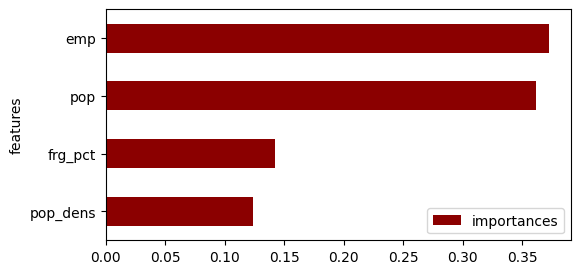

In [49]:
cols = X2_train.columns

# Derive feature importance from random forest
importances = rfc.feature_importances_
std = np.std([tree.feature_importances_ for tree in rfc.estimators_], axis=0)
indices = np.argsort(importances)[::-1]

# Print col-names and importances-values
print( cols[indices] )
print( importances[indices] )

# Barplot with feature importance
df_fi = pd.DataFrame({'features':cols,'importances': importances})
df_fi.sort_values('importances', inplace=True)
df_fi.plot(kind='barh', 
           y='importances', 
           x='features', 
           color='darkred', 
           figsize=(6,3))

### ROC curve and AUC

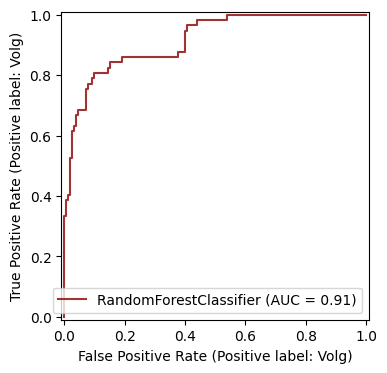

In [50]:
# Plot ROC curve and calculate AUC
plt.figure(figsize=(6,4))
ax = plt.gca()
rfc_disp = RocCurveDisplay.from_estimator(rfc, 
                                          X2_test, 
                                          y2_test, 
                                          ax=ax,
                                          alpha=0.8,
                                          c="darkred")
plt.show()

### Jupyter notebook --footer info-- (please always provide this at the end of each submitted notebook)

In [51]:
import platform
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Linux | 6.8.0-1030-azure
Datetime: 2025-12-12 23:23:05
Python Version: 3.11.14
-----------------------------------
